<a href="https://colab.research.google.com/github/njwbilll/Tugas-5_Grokking-Deep-Learning-MANNING_Najwa-Bilqis-Al-Khalidah/blob/main/05_Generalizing_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 5: Generalizing Gradient Descent

## Referensi

Grokking Deep Learning - Andrew W. Trask

---

## Learning Objectives

Pada chapter ini kita akan mempelajari:

1. Generalisasi gradient descent.
2. Training dengan multiple inputs.
3. Training dengan multiple outputs.
4. Error vector.
5. Weight update pada banyak parameter.
6. Intuisi dasar optimisasi pada neural network yang lebih kompleks.

---

## Ringkasan Chapter

Pada Chapter 4 kita mempelajari bagaimana neural network dengan satu input dan satu weight dapat belajar menggunakan gradient descent.

Pada chapter ini konsep tersebut diperluas sehingga dapat digunakan pada neural network yang memiliki banyak input dan banyak output.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("Chapter 5 Loaded")


Chapter 5 Loaded



# 1. Dari Satu Weight ke Banyak Weight

Pada dunia nyata, model jarang memiliki satu parameter saja.

Biasanya terdapat banyak input dan banyak weight yang harus diperbarui secara bersamaan.


In [2]:

inputs = np.array([8.5, 7.0, 3.0])
weights = np.array([0.1, 0.2, -0.1])

prediction = np.dot(inputs, weights)

print(prediction)


1.95



# 2. Prediksi Menggunakan Banyak Input

Prediksi dihitung menggunakan dot product.

Formula:

prediction = inputs · weights


In [3]:

prediction = np.dot(inputs, weights)
print("Prediction:", prediction)


Prediction: 1.95



# 3. Menghitung Error

Error tetap dihitung sebagai selisih antara target dan prediksi.


In [4]:

target = 1.0

error = (target - prediction) ** 2

print("Error:", error)


Error: 0.9025



# 4. Mengapa Semua Weight Harus Diperbarui?

Karena setiap weight berkontribusi terhadap prediksi akhir.

Jika prediksi salah, semua parameter yang berpengaruh harus diperbaiki.


In [5]:

for i,w in enumerate(weights):
    print(f"Weight {i+1}: {w}")


Weight 1: 0.1
Weight 2: 0.2
Weight 3: -0.1



# 5. Gradient untuk Banyak Weight

Setiap weight memiliki gradient masing masing.

Gradient vector:

gradient = error × input


In [6]:

prediction = np.dot(inputs, weights)

gradient = (prediction - target) * inputs

print(gradient)


[8.075 6.65  2.85 ]



# 6. Weight Update Vector

Update dilakukan pada seluruh weight secara bersamaan.


In [7]:

learning_rate = 0.01

new_weights = weights - learning_rate * gradient

print(new_weights)


[ 0.01925  0.1335  -0.1285 ]



# 7. Satu Langkah Training Lengkap


In [8]:

weights = np.array([0.1,0.2,-0.1])

prediction = np.dot(inputs, weights)

gradient = (prediction - target) * inputs

weights -= 0.01 * gradient

print(weights)


[ 0.01925  0.1335  -0.1285 ]



# 8. Training Berulang

Neural network belajar melalui banyak iterasi.


In [9]:

weights = np.array([0.1,0.2,-0.1])

loss_history = []

for _ in range(50):

    prediction = np.dot(inputs, weights)

    loss = (target - prediction) ** 2

    loss_history.append(loss)

    gradient = (prediction - target) * inputs

    weights -= 0.01 * gradient

print(weights)


[ 0.03800384  0.14894434 -0.121881  ]



# 9. Visualisasi Penurunan Error


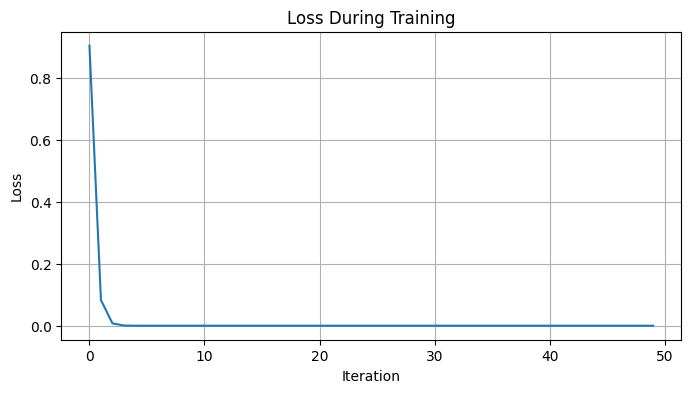

In [10]:

plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.title("Loss During Training")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()



# 10. Multiple Outputs

Selain banyak input, model juga dapat memiliki banyak output.


In [11]:

inputs = np.array([8.5,7.0,3.0])

weights = np.array([
    [0.1,0.1,-0.3],
    [0.1,0.2,0.0],
    [0.0,1.3,0.1]
])

predictions = np.dot(weights, inputs)

print(predictions)


[0.65 2.25 9.4 ]



# 11. Error Vector

Karena output lebih dari satu, maka error juga berbentuk vector.


In [12]:

targets = np.array([0.1,1.0,0.1])

error_vector = predictions - targets

print(error_vector)


[0.55 1.25 9.3 ]



# 12. Mean Squared Error

Salah satu cara menggabungkan seluruh error adalah menggunakan Mean Squared Error.


In [13]:

mse = np.mean(error_vector ** 2)

print("MSE:", mse)


MSE: 29.451666666666668



# 13. Matriks Weight

Pada neural network modern, weight biasanya disimpan dalam bentuk matriks.


In [14]:

print("Shape:", weights.shape)


Shape: (3, 3)



# 14. Hubungan Matrix dan Deep Learning

Semakin besar neural network, semakin besar pula matriks weight yang digunakan.

GPU sangat efektif karena dapat mempercepat operasi matriks dalam jumlah besar.



# 15. Visualisasi Weight Matrix


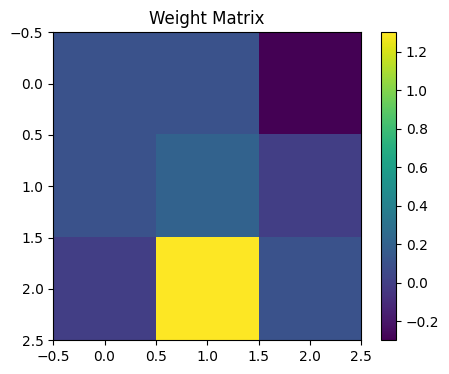

In [15]:

plt.figure(figsize=(5,4))
plt.imshow(weights)
plt.title("Weight Matrix")
plt.colorbar()
plt.show()



# 16. Intuisi Optimisasi

Tujuan optimisasi adalah menemukan kombinasi weight yang menghasilkan error minimum.

Gradient descent merupakan salah satu algoritma optimisasi paling sederhana.



# 17. Efek Learning Rate

Learning rate menentukan kecepatan pembelajaran model.


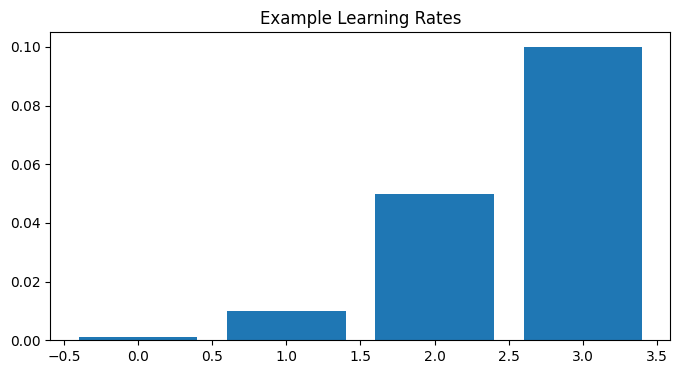

In [16]:

rates = [0.001,0.01,0.05,0.1]

plt.figure(figsize=(8,4))
plt.bar(range(len(rates)), rates)
plt.title("Example Learning Rates")
plt.show()



# 18. Studi Kasus Mini

Misalkan kita ingin memprediksi performa atlet berdasarkan:

* Latihan
* Tidur
* Nutrisi

Model dapat belajar dengan memperbarui seluruh weight berdasarkan error yang diperoleh.


In [17]:

athlete = np.array([9,8,7])
weights = np.array([0.2,0.3,0.1])

score = np.dot(athlete, weights)

print(score)


4.9



# 19. Key Takeaways

1. Gradient descent dapat digeneralisasi untuk banyak weight.
2. Setiap parameter memiliki gradient sendiri.
3. Weight diperbarui secara bersamaan.
4. Multiple outputs menghasilkan error vector.
5. Operasi matriks menjadi fondasi deep learning modern.



# 20. Chapter Summary

Pada chapter ini kita mempelajari:

* Generalisasi gradient descent
* Multiple inputs
* Multiple outputs
* Error vector
* Weight matrix
* Optimisasi banyak parameter

Konsep ini menjadi jembatan menuju neural network yang lebih besar dan lebih kompleks pada chapter berikutnya.
